# Pandas: Basics to Expert

A single, self-contained tour of **pandas** — from your first `Series` to expert-level
idioms, performance tuning, and the gotchas that bite everyone at least once.

**How to use this notebook:** run it top to bottom. Every section builds small,
in-memory datasets, so nothing here needs a download, a GPU, or more than a few
seconds of CPU.

## Table of contents

1. [Setup & the two core objects](#1)
2. [Creating Series and DataFrames](#2)
3. [Inspecting data](#3)
4. [Data types (incl. nullable & Arrow-backed)](#4)
5. [Reading & writing files](#5)
6. [Selection & indexing: `loc`, `iloc`, boolean masks, `query`](#6)
7. [Assignment, chained indexing & Copy-on-Write](#7)
8. [Cleaning: missing data, duplicates, strings, type fixes](#8)
9. [Operations & alignment (the silent gotcha)](#9)
10. [GroupBy: split–apply–combine](#10)
11. [Combining tables: `concat`, `merge`, `join`, `merge_asof`](#11)
12. [Reshaping: pivot, melt, stack/unstack, explode](#12)
13. [MultiIndex](#13)
14. [Time series: resample, rolling, shift](#14)
15. [Categoricals & memory optimization](#15)
16. [Performance: vectorize, `eval`/`query`, avoid `apply`](#16)
17. [Idiomatic pandas: method chaining, `assign`, `pipe`](#17)
18. [Expert corner: custom accessors, Styler, testing, interop](#18)
19. [Quick plotting tour](#19)
20. [Gotchas cheat sheet](#20)


<a id="1"></a>
## 1. Setup & the two core objects

Pandas has exactly **two** data structures you must know:

| Object | What it is | Think of it as |
|---|---|---|
| `Series` | 1-D array **with an index** (labels) | one column of a spreadsheet |
| `DataFrame` | 2-D table of columns that share a row index | the whole spreadsheet |

Everything else — GroupBy, Resampler, Styler — is a *view or helper* around these two.
The index is what separates pandas from NumPy: operations align **by label**, not by
position.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)      # reproducible randomness for the whole notebook
pd.set_option("display.max_rows", 12)
pd.set_option("display.precision", 3)

print("pandas :", pd.__version__)
print("numpy  :", np.__version__)

pandas : 2.3.0
numpy  : 2.3.1


<a id="2"></a>
## 2. Creating Series and DataFrames

A `Series` = values + index + (optional) name. If you don't give an index you get
`0, 1, 2, ...` (a `RangeIndex`, which is free — it stores only start/stop/step).

In [2]:
s = pd.Series([9.1, 8.7, 9.4], index=["alice", "bob", "carol"], name="rating")
s

alice    9.1
bob      8.7
carol    9.4
Name: rating, dtype: float64

In [3]:
# The three parts you should always be able to point at:
print("values:", s.to_numpy())     # the data          -> NumPy array
print("index :", s.index.tolist()) # the labels
print("name  :", s.name)           # the column name it would get inside a DataFrame
print("dtype :", s.dtype)

values: [9.1 8.7 9.4]
index : ['alice', 'bob', 'carol']
name  : rating
dtype : float64


### DataFrames: the four creation patterns you'll actually use

1. **dict of columns** (most common — column-oriented, like the data usually arrives)
2. **list of dicts / records** (row-oriented, like JSON APIs return)
3. **from a NumPy array** + column names
4. **from files** (section 5)

In [4]:
# 1) dict of columns
df = pd.DataFrame({
    "name":  ["alice", "bob", "carol", "dave", "eve", "frank"],
    "dept":  ["eng", "eng", "sales", "sales", "hr", "eng"],
    "salary": [95_000, 87_000, 72_000, 68_000, 61_000, 102_000],
    "hired": pd.to_datetime(["2019-03-01", "2020-07-15", "2018-11-20",
                             "2021-01-05", "2022-06-30", "2017-08-12"]),
    "remote": [True, False, False, True, True, False],
})
df

,name,dept,salary,hired,remote
0,alice,eng,95000,2019-03-01,True
1,bob,eng,87000,2020-07-15,False
2,carol,sales,72000,2018-11-20,False
3,dave,sales,68000,2021-01-05,True
4,eve,hr,61000,2022-06-30,True
5,frank,eng,102000,2017-08-12,False


In [5]:
# 2) list of records (row-oriented) — same result
records = [{"name": "alice", "dept": "eng"}, {"name": "bob", "dept": "sales"}]
pd.DataFrame(records)

,name,dept
0,alice,eng
1,bob,sales


In [6]:
# 3) from a NumPy array
pd.DataFrame(rng.integers(0, 10, size=(3, 4)), columns=list("ABCD"))

,A,B,C,D
0,0,7,6,4
1,4,8,0,6
2,2,0,5,9


<a id="3"></a>
## 3. Inspecting data

The first five methods to run on **any** new DataFrame, in order:
`head()` → `info()` → `describe()` → `nunique()` / `value_counts()` → `isna().sum()`.
`info()` is the single most information-dense call: shape, dtypes, non-null counts,
and memory usage in one screen.

In [7]:
df.info(memory_usage="deep")   # "deep" also counts the strings' actual bytes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   name    6 non-null      object        
 1   dept    6 non-null      object        
 2   salary  6 non-null      int64         
 3   hired   6 non-null      datetime64[ns]
 4   remote  6 non-null      bool          
dtypes: bool(1), datetime64[ns](1), int64(1), object(2)
memory usage: 868.0 bytes


In [8]:
df.describe()                       # numeric columns only, by default

,salary,hired
count,6.000,6
mean,80833.333,2019-12-14 00:00:00
min,61000.000,2017-08-12 00:00:00
25%,69000.000,2018-12-15 06:00:00
50%,79500.000,2019-11-07 00:00:00
75%,93000.000,2020-11-22 12:00:00
max,102000.000,2022-06-30 00:00:00
std,16265.505,NaN


In [9]:
df.describe(include="object")       # or include="all" for everything

,name,dept
count,6,6
unique,6,3
top,alice,eng
freq,1,3


In [10]:
df["dept"].value_counts()           # frequency table — you will use this daily

dept
eng      3
sales    2
hr       1
Name: count, dtype: int64

In [11]:
# Quick shape/dtype checks
print("shape  :", df.shape)
print("columns:", df.columns.tolist())
df.dtypes

shape  : (6, 5)
columns: ['name', 'dept', 'salary', 'hired', 'remote']


name              object
dept              object
salary             int64
hired     datetime64[ns]
remote              bool
dtype: object

<a id="4"></a>
## 4. Data types

Dtypes decide **speed, memory, and what operations exist**. The big picture:

| dtype | backed by | missing value | note |
|---|---|---|---|
| `int64`, `float64`, `bool` | NumPy | `int`/`bool` **can't hold NaN** → silently upcast to float/object | classic default |
| `object` | Python objects | `NaN` | slow; usually strings — avoid when possible |
| `datetime64[ns]`, `timedelta64[ns]` | NumPy | `NaT` | unlocks the `.dt` accessor |
| `category` | codes + lookup table | `NaN` | huge memory win for low-cardinality strings |
| `Int64`, `Float64`, `boolean`, `string` (capitalized!) | pandas masked arrays | `pd.NA` | *nullable* dtypes — int columns can finally have missing values |
| `int64[pyarrow]`, `string[pyarrow]`, ... | Apache Arrow | `pd.NA` | fast strings, interop with Parquet/Polars |

**The classic trap:** put one `NaN` into an int column and pandas silently converts the
whole column to `float64` (that's why you see `3.0` where you wrote `3`). Nullable
`Int64` fixes this.

In [12]:
# NaN forces int -> float with NumPy dtypes...
classic = pd.Series([1, 2, None])
print("classic :", classic.dtype, "->", classic.tolist())

# ...but nullable Int64 keeps integers intact
nullable = pd.Series([1, 2, None], dtype="Int64")
print("nullable:", nullable.dtype, "->", nullable.tolist())

classic : float64 -> [1.0, 2.0, nan]
nullable: Int64 -> [1, 2, <NA>]


In [13]:
# Convert an existing frame to nullable dtypes in one call
df.convert_dtypes().dtypes

name      string[python]
dept      string[python]
salary             Int64
hired     datetime64[ns]
remote           boolean
dtype: object

In [14]:
# Arrow-backed dtypes (pandas >= 2.0): fast strings, zero-copy Parquet
s_arrow = pd.Series(["fast", "strings", None], dtype="string[pyarrow]")
print(s_arrow.dtype)
s_arrow.str.upper()

string


0       FAST
1    STRINGS
2       <NA>
dtype: string

<a id="5"></a>
## 5. Reading & writing files

`read_csv` alone has ~50 parameters; these are the ones that matter:

- `usecols=` — read only the columns you need (big speed/memory win)
- `dtype=` — skip type inference, prevent the "ZIP code loses its leading zero" bug
- `parse_dates=` — get real datetimes instead of strings
- `na_values=` — declare your file's flavor of "missing" (`"N/A"`, `"-"`, ...)
- `chunksize=` — iterate a file too big for RAM in pieces

**Rule of thumb for formats:** CSV for humans and interchange, **Parquet** for anything
you'll read again — it stores dtypes (no re-parsing dates!), it's compressed, and it's
column-oriented so `columns=` reads are nearly free.

In [15]:
import io, tempfile, os

csv_text = '''name,dept,salary,hired,zip
alice,eng,95000,2019-03-01,07030
bob,eng,87000,2020-07-15,10001
carol,sales,N/A,2018-11-20,94105
'''

# io.StringIO lets us treat a string as a file — handy for tests and examples
loaded = pd.read_csv(
    io.StringIO(csv_text),
    dtype={"zip": "string"},        # keep the leading zero!
    parse_dates=["hired"],
    na_values=["N/A"],
)
print(loaded.dtypes)
loaded

name              object
dept              object
salary           float64
hired     datetime64[ns]
zip       string[python]
dtype: object


,name,dept,salary,hired,zip
0,alice,eng,95000.0,2019-03-01,07030
1,bob,eng,87000.0,2020-07-15,10001
2,carol,sales,NaN,2018-11-20,94105


In [16]:
# Round-trip through Parquet: dtypes survive, CSV would have lost them
tmp = os.path.join(tempfile.gettempdir(), "pandas_demo.parquet")
loaded.to_parquet(tmp)
back = pd.read_parquet(tmp, columns=["name", "hired"])   # column pruning
print(back.dtypes)
os.remove(tmp)
back

name             object
hired    datetime64[ns]
dtype: object

,name,hired
0,alice,2019-03-01
1,bob,2020-07-15
2,carol,2018-11-20


In [17]:
# Chunked reading pattern for files bigger than RAM
total = 0
for chunk in pd.read_csv(io.StringIO(csv_text), chunksize=2):
    total += chunk["salary"].sum()
print("salary total from chunks:", total)

salary total from chunks: 182000.0


<a id="6"></a>
## 6. Selection & indexing

The rule that prevents 90% of indexing confusion:

- **`.loc[rows, cols]`** — by **label** (and boolean masks). Slices are **inclusive** of the end.
- **`.iloc[rows, cols]`** — by **integer position**. Slices are **exclusive**, like Python lists.
- `df[...]` plain brackets — only for two things: a column name (`df["salary"]`) or a
  boolean mask (`df[mask]`). Anything fancier: use `.loc`.

Never mix them mentally: `.loc[0]` means *the row labeled 0*, which after sorting or
filtering is usually **not** the first row.

In [18]:
people = df.set_index("name")     # use names as row labels
people

,dept,salary,hired,remote
name,,,,
alice,eng,95000,2019-03-01,True
bob,eng,87000,2020-07-15,False
carol,sales,72000,2018-11-20,False
dave,sales,68000,2021-01-05,True
eve,hr,61000,2022-06-30,True
frank,eng,102000,2017-08-12,False


In [19]:
# .loc — label based, end-inclusive slices
people.loc["bob":"dave", ["dept", "salary"]]   # note: dave IS included

,dept,salary
name,,
bob,eng,87000
carol,sales,72000
dave,sales,68000


In [20]:
# .iloc — position based, end-exclusive (like lists)
people.iloc[0:2, 0:2]

,dept,salary
name,,
alice,eng,95000
bob,eng,87000


### Boolean masking — the workhorse

Combine conditions with `&` (and), `|` (or), `~` (not) — **not** Python's `and`/`or` —
and parenthesize every condition (comparison operators bind looser than `&`).

In [21]:
mask = (people["salary"] > 70_000) & (people["dept"] == "eng")
people[mask]

,dept,salary,hired,remote
name,,,,
alice,eng,95000,2019-03-01,True
bob,eng,87000,2020-07-15,False
frank,eng,102000,2017-08-12,False


In [22]:
# isin / between read better than chained comparisons
people[people["dept"].isin(["hr", "sales"])]

,dept,salary,hired,remote
name,,,,
carol,sales,72000,2018-11-20,False
dave,sales,68000,2021-01-05,True
eve,hr,61000,2022-06-30,True


In [23]:
# .query — the same filter as a string; shines with long conditions
top_eng = people.query("salary > 70_000 and dept == 'eng'")

# reference Python variables with @
threshold = 90_000
people.query("salary > @threshold")

,dept,salary,hired,remote
name,,,,
alice,eng,95000,2019-03-01,True
frank,eng,102000,2017-08-12,False


In [24]:
# Handy row-pickers
print(people["salary"].idxmax(), "earns the most")   # label of the max
people.nlargest(2, "salary")                          # top-k without a full sort

frank earns the most


,dept,salary,hired,remote
name,,,,
frank,eng,102000,2017-08-12,False
alice,eng,95000,2019-03-01,True


<a id="7"></a>
## 7. Assignment, chained indexing & Copy-on-Write

The most infamous pandas pitfall. **Chained indexing** —
`df[df.x > 0]["y"] = 1` — does two separate operations: the first may return a
*copy*, so the assignment lands on a throwaway object and your DataFrame is unchanged.

**The fix is always the same:** do it in **one** `.loc` call:
`df.loc[df.x > 0, "y"] = 1`.

Pandas 2.x offers **Copy-on-Write** mode (`pd.options.mode.copy_on_write = True`,
the default in pandas 3.0), which makes the rules simple: *every* derived object
behaves like a copy, and chained assignment simply never works instead of "sometimes
works". Turn it on in new code today.

In [25]:
demo = df.copy()

# WRONG (chained): may or may not modify demo, warns, and breaks under CoW
# demo[demo["dept"] == "eng"]["salary"] = 0     # <- don't do this

# RIGHT: one .loc with (row_condition, column)
demo.loc[demo["dept"] == "eng", "salary"] = 0
demo.head(3)

,name,dept,salary,hired,remote
0,alice,eng,0,2019-03-01,True
1,bob,eng,0,2020-07-15,False
2,carol,sales,72000,2018-11-20,False


In [26]:
# Adding / deriving columns
demo = df.copy()
demo["salary_k"] = demo["salary"] / 1000              # simple assignment
demo["tenure_yrs"] = (pd.Timestamp("2026-07-07") - demo["hired"]).dt.days / 365.25
demo.head(3)

,name,dept,salary,hired,remote,salary_k,tenure_yrs
0,alice,eng,95000,2019-03-01,True,95.0,7.351
1,bob,eng,87000,2020-07-15,False,87.0,5.977
2,carol,sales,72000,2018-11-20,False,72.0,7.628


In [27]:
# assign() does the same but returns a NEW frame -> chainable, original untouched
df.assign(
    salary_k=lambda d: d["salary"] / 1000,
    senior=lambda d: d["salary_k"] > 80,       # can use columns created above it!
).head(3)

,name,dept,salary,hired,remote,salary_k,senior
0,alice,eng,95000,2019-03-01,True,95.0,True
1,bob,eng,87000,2020-07-15,False,87.0,True
2,carol,sales,72000,2018-11-20,False,72.0,False


<a id="8"></a>
## 8. Cleaning: missing data, duplicates, strings, type fixes

Real data is dirty. The cleaning toolkit:

| Task | Tools |
|---|---|
| find missing | `isna()`, `isna().sum()`, `notna()` |
| drop missing | `dropna(subset=..., how=...)` |
| fill missing | `fillna(value/dict)`, `ffill()`, `bfill()`, `interpolate()` |
| duplicates | `duplicated()`, `drop_duplicates(subset=..., keep=...)` |
| strings | the `.str` accessor — vectorized `str` methods |
| wrong types | `astype`, `pd.to_numeric(errors="coerce")`, `pd.to_datetime` |
| recode values | `replace`, `map` |

In [28]:
dirty = pd.DataFrame({
    "name":  ["  Alice ", "BOB", "carol", "carol", "dave", None],
    "age":   ["34", "29", "41", "41", "not available", "25"],
    "email": ["a@x.com", "b@x.com", "c@x.com", "c@x.com", None, "e@x.com"],
    "city":  ["NYC", "nyc", "New York", "New York", "SF", "SF"],
})
dirty

,name,age,email,city
0,Alice,34,a@x.com,NYC
1,BOB,29,b@x.com,nyc
2,carol,41,c@x.com,New York
3,carol,41,c@x.com,New York
4,dave,not available,None,SF
5,None,25,e@x.com,SF


In [29]:
# 1) Where is data missing?
dirty.isna().sum()

name     1
age      0
email    1
city     0
dtype: int64

In [30]:
cleaned = (
    dirty
    # 2) fix strings: strip whitespace, normalize case (vectorized, NaN-safe)
    .assign(name=lambda d: d["name"].str.strip().str.title())
    # 3) force numeric; junk like "not available" becomes NaN instead of crashing
    .assign(age=lambda d: pd.to_numeric(d["age"], errors="coerce"))
    # 4) recode aliases to one canonical value
    .assign(city=lambda d: d["city"].replace({"nyc": "NYC", "New York": "NYC"}))
    # 5) drop exact duplicate rows, keep the first
    .drop_duplicates()
    # 6) drop rows that are missing the column we actually require
    .dropna(subset=["name"])
)
cleaned

,name,age,email,city
0,Alice,34.0,a@x.com,NYC
1,Bob,29.0,b@x.com,NYC
2,Carol,41.0,c@x.com,NYC
4,Dave,NaN,None,SF


In [31]:
# Filling strategies — value, per-column dict, or neighbor fill
s = pd.Series([1.0, np.nan, np.nan, 4.0])
pd.DataFrame({
    "orig":        s,
    "fill_0":      s.fillna(0),
    "ffill":       s.ffill(),          # carry last valid value forward
    "interpolate": s.interpolate(),    # linear between neighbors
})

,orig,fill_0,ffill,interpolate
0,1.0,1.0,1.0,1.0
1,NaN,0.0,1.0,2.0
2,NaN,0.0,1.0,3.0
3,4.0,4.0,4.0,4.0


In [32]:
# .str is a mini string-toolkit: contains/extract/split all vectorized
emails = cleaned["email"].dropna()
pd.DataFrame({
    "user":   emails.str.split("@").str[0],
    "domain": emails.str.extract(r"@(.+)$")[0],   # regex capture group
    "is_x":   emails.str.contains("x.com", regex=False),
})

,user,domain,is_x
0,a,x.com,True
1,b,x.com,True
2,c,x.com,True


In [33]:
# map: element-wise lookup on a Series (dict, Series, or function)
sizes = cleaned["city"].map({"NYC": "large", "SF": "medium"})
sizes.tolist()

['large', 'large', 'large', 'medium']

<a id="9"></a>
## 9. Operations & alignment — the silent gotcha

Arithmetic between pandas objects aligns **by index label first**, then computes.
Labels that exist on only one side produce `NaN` — *silently*. This is pandas'
superpower (no more "did I sort both arrays the same way?") and its most surprising
behavior if you expect positional NumPy semantics.

In [34]:
a = pd.Series([10, 20, 30], index=["x", "y", "z"])
b = pd.Series([1, 2, 3],    index=["y", "z", "w"])
a + b        # x and w exist on one side only -> NaN

w     NaN
x     NaN
y    21.0
z    32.0
dtype: float64

In [35]:
# fill_value treats missing labels as a default instead of NaN
a.add(b, fill_value=0)

w     3.0
x    10.0
y    21.0
z    32.0
dtype: float64

In [36]:
# Row-wise broadcasting: DataFrame op Series matches Series index to COLUMNS
prices = pd.DataFrame({"apple": [1.0, 1.2], "banana": [0.5, 0.4]}, index=["mon", "tue"])
tax = pd.Series({"apple": 0.1, "banana": 0.05})
prices * (1 + tax)          # each column scaled by its own tax rate

,apple,banana
mon,1.10,0.525
tue,1.32,0.420


In [37]:
# Aggregations: axis=0 collapses rows (per-column), axis="columns" collapses columns
print(prices.mean())                 # per fruit
print(prices.mean(axis="columns"))   # per day

apple     1.10
banana    0.45
dtype: float64
mon    0.75
tue    0.80
dtype: float64


<a id="10"></a>
## 10. GroupBy: split–apply–combine

`groupby` splits rows into groups, applies something to each, and glues results back.
The three verbs — pick by **output shape**:

| verb | output | typical use |
|---|---|---|
| `agg` | **one row per group** | totals, means, counts |
| `transform` | **same shape as input** | group z-scores, "% of group total", fill NaN with group mean |
| `filter` | **subset of original rows** | keep only groups meeting a condition |

In [38]:
sales = pd.DataFrame({
    "region":  rng.choice(["north", "south", "west"], 120),
    "product": rng.choice(["widget", "gadget"], 120),
    "units":   rng.integers(1, 50, 120),
    "price":   rng.uniform(10, 100, 120).round(2),
})
sales["revenue"] = sales["units"] * sales["price"]
sales.head()

,region,product,units,price,revenue
0,west,widget,10,43.63,436.30
1,west,gadget,17,18.50,314.50
2,west,gadget,33,77.21,2547.93
3,west,widget,8,33.62,268.96
4,south,gadget,34,94.31,3206.54


In [39]:
# agg: one row per group. Named aggregation = clean output columns.
summary = sales.groupby("region").agg(
    total_rev=("revenue", "sum"),
    avg_units=("units", "mean"),
    n_orders=("units", "size"),
    best_sale=("revenue", "max"),
)
summary

,total_rev,avg_units,n_orders,best_sale
region,,,,
north,34030.99,21.452,31,3170.52
south,55202.10,26.419,43,3615.92
west,62017.41,24.826,46,4080.66


In [40]:
# Group by several keys -> MultiIndex result (more in section 13)
sales.groupby(["region", "product"])["revenue"].sum()

region  product
north   gadget     12288.76
        widget     21742.23
south   gadget     19850.45
        widget     35351.65
west    gadget     34737.82
        widget     27279.59
Name: revenue, dtype: float64

In [41]:
# transform: broadcast group stats back to every row — same length as input
sales["region_share"] = sales["revenue"] / sales.groupby("region")["revenue"].transform("sum")
sales.head(3)

,region,product,units,price,revenue,region_share
0,west,widget,10,43.63,436.30,0.007
1,west,gadget,17,18.50,314.50,0.005
2,west,gadget,33,77.21,2547.93,0.041


In [42]:
# filter: keep only rows of groups that pass a test
big_regions = sales.groupby("region").filter(lambda g: g["revenue"].sum() > 60_000)
big_regions["region"].unique()

array(['west'], dtype=object)

In [43]:
# Classic interview question: the top-revenue ROW per region.
# idxmax gives each group's row label; .loc pulls those rows. No apply needed.
sales.loc[sales.groupby("region")["revenue"].idxmax()]

,region,product,units,price,revenue,region_share
65,north,widget,36,88.07,3170.52,0.093
111,south,gadget,44,82.18,3615.92,0.066
11,west,widget,46,88.71,4080.66,0.066


**GroupBy tips that separate intermediate from expert:**

- Prefer built-in aggregations (`"sum"`, `"mean"`) over lambdas — they run in Cython, often 10–100× faster.
- `as_index=False` keeps group keys as columns (like SQL `GROUP BY`).
- With categorical keys pass `observed=True` to skip empty category combinations (the future default).
- `.groupby(...).ngroup()` gives you a group id per row; `.cumcount()` numbers rows within each group.

In [44]:
# cumcount: "nth purchase per region" — no loop required
sales["nth_in_region"] = sales.sort_index().groupby("region").cumcount() + 1
sales.groupby("region", as_index=False).agg(orders=("nth_in_region", "max")).head()

,region,orders
0,north,31
1,south,43
2,west,46


<a id="11"></a>
## 11. Combining tables

- **`pd.concat`** — stack frames **vertically** (more rows) or side-by-side. Pure glue, no matching logic.
- **`pd.merge`** — SQL-style **join on key columns**. The one to master.
- **`df.join`** — convenience merge **on the index**.
- **`pd.merge_asof`** — "nearest key ≤" join, gold for time-series (trades↔quotes).

`merge`'s `how=` mirrors SQL: `inner` (default!), `left`, `right`, `outer`, plus
`cross`. Two expert flags: `indicator=True` shows where each row came from, and
`validate="one_to_many"` makes pandas *raise* if your key assumptions are wrong —
cheap insurance against silent row explosions.

In [45]:
employees = pd.DataFrame({
    "name": ["alice", "bob", "carol", "dave"],
    "dept_id": [1, 1, 2, 4],                    # dave's dept 4 doesn't exist!
})
departments = pd.DataFrame({
    "dept_id": [1, 2, 3],
    "dept_name": ["engineering", "sales", "hr"],  # hr has no employees
})

pd.merge(employees, departments, on="dept_id", how="left")   # keep all employees

,name,dept_id,dept_name
0,alice,1,engineering
1,bob,1,engineering
2,carol,2,sales
3,dave,4,NaN


In [46]:
# indicator=True: audit the join — where did each row match?
audit = pd.merge(employees, departments, on="dept_id", how="outer", indicator=True)
audit

,name,dept_id,dept_name,_merge
0,alice,1,engineering,both
1,bob,1,engineering,both
2,carol,2,sales,both
3,NaN,3,hr,right_only
4,dave,4,NaN,left_only


In [47]:
# validate: crash EARLY if the right side unexpectedly has duplicate keys
try:
    dup_depts = pd.concat([departments, departments])          # simulate bad data
    pd.merge(employees, dup_depts, on="dept_id", validate="many_to_one")
except pd.errors.MergeError as e:
    print("MergeError caught:", e)

MergeError caught: Merge keys are not unique in right dataset; not a many-to-one merge


In [48]:
# concat: stack quarterly files, keys= remembers the source
q1 = pd.DataFrame({"rev": [10, 20]}, index=["jan", "feb"])
q2 = pd.DataFrame({"rev": [30, 40]}, index=["apr", "may"])
pd.concat([q1, q2], keys=["Q1", "Q2"])

rev
Q1 jan   10
   feb   20
Q2 apr   30
   may   40

In [49]:
# merge_asof: match each trade to the latest quote AT OR BEFORE it (sorted required)
day = "2026-07-07 "
quotes = pd.DataFrame({"time": pd.to_datetime([day + t for t in ["10:00:00", "10:00:03", "10:00:05"]]),
                       "bid": [99.9, 100.1, 100.3]})
trades = pd.DataFrame({"time": pd.to_datetime([day + t for t in ["10:00:01", "10:00:04", "10:00:06"]]),
                       "qty": [100, 50, 75]})
pd.merge_asof(trades, quotes, on="time")

,time,qty,bid
0,2026-07-07 10:00:01,100,99.9
1,2026-07-07 10:00:04,50,100.1
2,2026-07-07 10:00:06,75,100.3


<a id="12"></a>
## 12. Reshaping: wide ↔ long

Two shapes of the same data:

- **Long/tidy** — one observation per row (`date, city, temp`). Best for groupby, plotting, storage.
- **Wide** — one row per entity, one column per variable (`date | NYC | SF`). Best for humans and spreadsheets.

| direction | tool |
|---|---|
| long → wide | `pivot` (crashes on duplicates — good!), `pivot_table` (aggregates duplicates) |
| wide → long | `melt` |
| columns ↔ index levels | `stack` / `unstack` |
| list column → rows | `explode` |
| category column → 0/1 columns | `pd.get_dummies` |

In [50]:
long = pd.DataFrame({
    "date": pd.to_datetime(["2026-01-01", "2026-01-01", "2026-01-02", "2026-01-02"]),
    "city": ["NYC", "SF", "NYC", "SF"],
    "temp": [30, 55, 28, 57],
    "humid": [60, 70, 65, 72],
})
long

,date,city,temp,humid
0,2026-01-01,NYC,30,60
1,2026-01-01,SF,55,70
2,2026-01-02,NYC,28,65
3,2026-01-02,SF,57,72


In [51]:
wide = long.pivot(index="date", columns="city", values="temp")
wide

city,NYC,SF
date,,
2026-01-01,30,55
2026-01-02,28,57


In [52]:
# pivot_table = pivot + aggregation of duplicates + margins (subtotals)
sales.pivot_table(index="region", columns="product", values="revenue",
                  aggfunc="sum", margins=True)

product,gadget,widget,All
region,,,
north,12288.76,21742.23,34030.99
south,19850.45,35351.65,55202.10
west,34737.82,27279.59,62017.41
All,66877.03,84373.47,151250.50


In [53]:
# melt: back to long. id_vars stay, everything else becomes (variable, value) pairs
long.melt(id_vars=["date", "city"], var_name="measure", value_name="reading").head()

,date,city,measure,reading
0,2026-01-01,NYC,temp,30
1,2026-01-01,SF,temp,55
2,2026-01-02,NYC,temp,28
3,2026-01-02,SF,temp,57
4,2026-01-01,NYC,humid,60


In [54]:
# explode: one row per element of a list-valued cell
orders = pd.DataFrame({"order": [1, 2], "items": [["apple", "bread"], ["milk"]]})
orders.explode("items")

,order,items
0,1,apple
0,1,bread
1,2,milk


In [55]:
# get_dummies: one-hot encode for ML
pd.get_dummies(long["city"], prefix="city", dtype=int).head()

,city_NYC,city_SF
0,1,0
1,0,1
2,1,0
3,0,1


<a id="13"></a>
## 13. MultiIndex

A hierarchical index — several label levels per row. You rarely *build* one by hand;
they appear from `groupby` with multiple keys, `pivot_table`, and `stack`. You need
three skills: **select** from one, **flatten** one, and **move levels** between rows
and columns with `stack`/`unstack`.

In [56]:
multi = sales.groupby(["region", "product"])["revenue"].sum()
multi

region  product
north   gadget     12288.76
        widget     21742.23
south   gadget     19850.45
        widget     35351.65
west    gadget     34737.82
        widget     27279.59
Name: revenue, dtype: float64

In [57]:
# Selecting: outer level, exact pair, or cross-section of an inner level
print(multi.loc["north"], "\n")           # everything in north
print(multi.loc[("north", "widget")])       # scalar
multi.xs("widget", level="product")         # widget across all regions

product
gadget    12288.76
widget    21742.23
Name: revenue, dtype: float64 

21742.23


region
north    21742.23
south    35351.65
west     27279.59
Name: revenue, dtype: float64

In [58]:
# unstack: move the inner index level into columns -> a 2-D view
table = multi.unstack("product")
table

product,gadget,widget
region,,
north,12288.76,21742.23
south,19850.45,35351.65
west,34737.82,27279.59


In [59]:
# stack is the inverse; and slicing both levels uses pd.IndexSlice
idx = pd.IndexSlice
multi.loc[idx[["north", "west"], "gadget"]]

region  product
north   gadget     12288.76
west    gadget     34737.82
Name: revenue, dtype: float64

In [60]:
# Flatten when you're done — analysis-friendly columns again
flat = multi.reset_index()
flat.head(3)

,region,product,revenue
0,north,gadget,12288.76
1,north,widget,21742.23
2,south,gadget,19850.45


<a id="14"></a>
## 14. Time series

Pandas was born at a hedge fund; time series is where it shines. Core moves:

- `pd.to_datetime` / `pd.date_range` create datetimes; the **`.dt` accessor** extracts parts.
- A `DatetimeIndex` unlocks **partial string slicing**: `df.loc["2026-03"]` = all of March.
- **`resample`** = groupby over time buckets (`"D"`, `"W"`, `"ME"` month-end, `"h"`...).
- **`rolling` / `expanding` / `ewm`** = sliding, cumulative, exponentially-weighted windows.
- **`shift` / `diff` / `pct_change`** = compare each row to its past.

In [61]:
dates = pd.date_range("2026-01-01", periods=90, freq="D")
ts = pd.DataFrame({
    "visits": (200 + np.arange(90) * 1.5                       # trend
               + 40 * np.sin(np.arange(90) * 2 * np.pi / 7)     # weekly cycle
               + rng.normal(0, 15, 90)).round(0),               # noise
}, index=dates)
ts.head()

,visits
2026-01-01,196.0
2026-01-02,235.0
2026-01-03,246.0
2026-01-04,216.0
2026-01-05,162.0


In [62]:
# .dt accessor (on columns) / index attributes: pull out parts
ts_parts = ts.reset_index(names="date")
ts_parts["dow"] = ts_parts["date"].dt.day_name()
ts_parts["week"] = ts_parts["date"].dt.isocalendar().week
ts_parts.head(3)

,date,visits,dow,week
0,2026-01-01,196.0,Thursday,1
1,2026-01-02,235.0,Friday,1
2,2026-01-03,246.0,Saturday,1


In [63]:
# Partial string slicing — an entire month by label
ts.loc["2026-02"].shape

(28, 1)

In [64]:
# resample: weekly totals, monthly means ("ME" = month end)
weekly = ts.resample("W")["visits"].sum()
print(weekly.head(3))
ts.resample("ME")["visits"].agg(["mean", "max"])

2026-01-04     893.0
2026-01-11    1461.0
2026-01-18    1605.0
Freq: W-SUN, Name: visits, dtype: float64


,mean,max
2026-01-31,229.097,311.0
2026-02-28,264.893,331.0
2026-03-31,312.677,370.0


In [65]:
# rolling / ewm: smoothing; shift/pct_change: change vs the past
ts["roll7"] = ts["visits"].rolling(7).mean()          # NaN for first 6 (need full window)
ts["ewm7"]  = ts["visits"].ewm(span=7).mean()          # no warm-up NaNs, recent-weighted
ts["wow"]   = ts["visits"].pct_change(7)               # week-over-week % change
ts.iloc[5:9]

,visits,roll7,ewm7,wow
2026-01-06,173.0,NaN,194.839,NaN
2026-01-07,204.0,204.571,197.482,NaN
2026-01-08,187.0,203.286,194.570,-0.046
2026-01-09,256.0,206.286,211.174,0.089


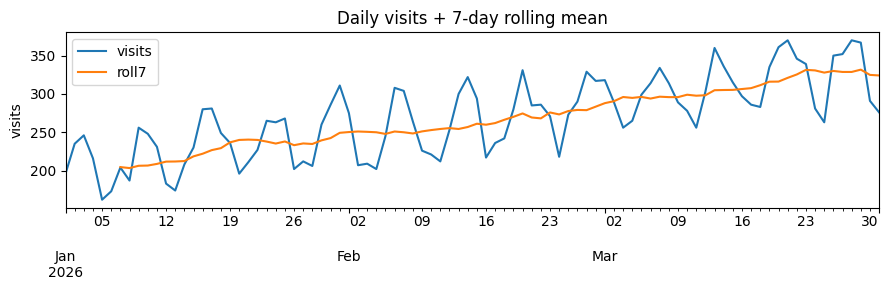

In [66]:
ax = ts[["visits", "roll7"]].plot(figsize=(9, 3), title="Daily visits + 7-day rolling mean")
ax.set_ylabel("visits")
plt.tight_layout()

In [67]:
# Timezones: localize (attach a zone) then convert (change the zone)
utc = pd.Series([1, 2], index=pd.to_datetime(["2026-07-01 12:00", "2026-07-01 13:00"]))
utc.index = utc.index.tz_localize("UTC").tz_convert("Asia/Kolkata")
utc

2026-07-01 17:30:00+05:30    1
2026-07-01 18:30:00+05:30    2
dtype: int64

<a id="15"></a>
## 15. Categoricals & memory optimization

A `category` column stores each unique value **once** plus a small integer code per
row. For a million-row column with 3 distinct strings that's ~8 MB → ~1 MB, and
groupbys get faster too. Categories can also be **ordered**, enabling `<` comparisons
and correct sorting for things like `small < medium < large`.

Memory checklist for big frames: strings → `category` (if low cardinality),
`float64` → `float32`, `int64` → smallest int that fits, load with `usecols`.

In [68]:
n = 200_000
big = pd.DataFrame({
    "city": rng.choice(["NYC", "SF", "LA"], n),
    "score": rng.uniform(0, 1, n),
    "count": rng.integers(0, 100, n),
})
before = big.memory_usage(deep=True).sum()

opt = big.assign(
    city=big["city"].astype("category"),
    score=big["score"].astype("float32"),
    count=pd.to_numeric(big["count"], downcast="integer"),
)
after = opt.memory_usage(deep=True).sum()
print(f"before: {before/1e6:5.1f} MB")
print(f"after : {after/1e6:5.1f} MB  ({before/after:.1f}x smaller)")
opt.dtypes

before:  13.5 MB
after :   1.2 MB  (11.2x smaller)


city     category
score     float32
count        int8
dtype: object

In [69]:
# Ordered categories: real-world sort order instead of alphabetical
sizes = pd.Series(["medium", "small", "large", "small"]).astype(
    pd.CategoricalDtype(["small", "medium", "large"], ordered=True))
print(sizes.sort_values().tolist())      # not alphabetical!
sizes > "small" 

['small', 'small', 'medium', 'large']


0     True
1    False
2     True
3    False
dtype: bool

In [70]:
# cut / qcut: turn continuous values into categories (binning)
scores = pd.Series(rng.uniform(0, 100, 8).round(1))
pd.DataFrame({
    "score": scores,
    "grade": pd.cut(scores, bins=[0, 50, 80, 100], labels=["fail", "pass", "excellent"]),
    "quartile": pd.qcut(scores, 4, labels=["Q1", "Q2", "Q3", "Q4"]),   # equal-count bins
})

,score,grade,quartile
0,91.2,excellent,Q4
1,65.5,pass,Q3
2,40.0,fail,Q2
3,13.6,fail,Q1
4,68.2,pass,Q3
5,43.7,fail,Q2
6,93.4,excellent,Q4
7,2.7,fail,Q1


<a id="16"></a>
## 16. Performance: the speed hierarchy

From fastest to slowest — always try the level above before dropping down:

1. **Vectorized column ops** (`df.a * df.b`, `np.where`, `.str`, `.dt`) — C speed.
2. **Built-in methods** (`clip`, `where`, `mask`, `select_dtypes`).
3. `df.itertuples()` — if you truly must loop, this beats `iterrows` ~10×.
4. **`df.apply(axis=1)` — a Python loop in disguise.** Almost never necessary.
5. `df.iterrows()` — slowest, and it copies each row into a Series (dtype loss!).

The following cell measures the same computation three ways.

In [71]:
import timeit

perf = pd.DataFrame({"a": rng.uniform(0, 1, 100_000), "b": rng.uniform(0, 1, 100_000)})

def with_apply(df):    return df.apply(lambda r: r["a"] * r["b"] if r["a"] > 0.5 else 0.0, axis=1)
def with_itertuples(df): return [t.a * t.b if t.a > 0.5 else 0.0 for t in df.itertuples()]
def vectorized(df):    return np.where(df["a"] > 0.5, df["a"] * df["b"], 0.0)

for fn in (with_apply, with_itertuples, vectorized):
    t = timeit.timeit(lambda: fn(perf), number=3) / 3
    print(f"{fn.__name__:16s}: {t*1000:8.1f} ms")

with_apply      :   1059.2 ms
with_itertuples :     66.8 ms
vectorized      :      0.8 ms


In [72]:
# Multi-branch conditions without apply: np.select
conditions = [perf["a"] > 0.8, perf["a"] > 0.5]
choices    = ["high", "mid"]
perf["band"] = np.select(conditions, choices, default="low")
perf["band"].value_counts()

band
low     50361
mid     29756
high    19883
Name: count, dtype: int64

In [73]:
# query/eval use the numexpr engine when available — and read beautifully
perf.query("a > 0.9 and b < 0.1").shape

(1017, 3)

**Other levers when things get slow:**

- `category` dtype before groupby on strings (section 15).
- `merge` on int/category keys beats string keys.
- Chunked reading (section 5) or switch the file to Parquet.
- `engine="pyarrow"` in `read_csv`, or Arrow-backed dtypes throughout.
- Beyond a single machine's comfort: DuckDB or Polars interop — both convert
  to/from pandas nearly for free.

<a id="17"></a>
## 17. Idiomatic pandas: method chaining

Expert pandas code is written as **pipelines**: each step takes a frame and returns a
new one, wrapped in parentheses so it reads top-to-bottom like a recipe. No `df2`,
`df_final`, `df_final_v3` litter, no stale intermediate state, trivially debuggable
(comment out a line).

Key enablers: `assign` (add columns), `query`/`loc` (filter), `pipe` (drop any custom
function into the chain), and lambdas that receive *the frame as it is at that point
in the chain*.

In [74]:
def add_revenue_metrics(d, target):
    '''Custom step: anything df-in, df-out can join a chain via .pipe.'''
    return d.assign(vs_target=d["total_rev"] / target - 1)

report = (
    sales
    .query("units >= 5")                                     # 1. filter early
    .assign(revenue_k=lambda d: d["revenue"] / 1000)         # 2. derive
    .groupby(["region", "product"], as_index=False)          # 3. aggregate
    .agg(total_rev=("revenue_k", "sum"), orders=("units", "size"))
    .pipe(add_revenue_metrics, target=25)                    # 4. custom step
    .sort_values("total_rev", ascending=False)               # 5. present
    .reset_index(drop=True)
)
report

,region,product,total_rev,orders,vs_target
0,south,widget,35.300,24,0.412
1,west,gadget,34.468,22,0.379
2,west,widget,27.280,22,0.091
3,north,widget,21.681,19,-0.133
4,south,gadget,19.734,17,-0.211
5,north,gadget,12.008,9,-0.520


In [75]:
# Debugging inside a chain: .pipe(lambda d: print(...) or d) — peek without breaking it
_ = (
    sales
    .query("region == 'north'")
    .pipe(lambda d: print(f"after filter: {d.shape}") or d)
    .groupby("product")["revenue"].sum()
)

after filter: (31, 7)


<a id="18"></a>
## 18. Expert corner

Four things that mark production-grade pandas code:

1. **Custom accessors** — attach your domain's helpers to every DataFrame as `df.myns.method()`, without subclassing.
2. **`Styler`** — presentation-quality tables (heatmaps, formatting) straight from a frame.
3. **`pd.testing`** — proper equality assertions for tests (tolerances, dtype checks).
4. **Interop** — pandas as the hub: NumPy, Arrow, dicts, JSON, SQL.

In [76]:
@pd.api.extensions.register_dataframe_accessor("audit")
class AuditAccessor:
    def __init__(self, obj):
        self._obj = obj

    def missing_report(self):
        n = len(self._obj)
        pct = self._obj.isna().sum().mul(100 / max(n, 1))
        return pct[pct > 0].sort_values(ascending=False).rename("pct_missing")

dirty.audit.missing_report()      # now available on EVERY DataFrame

name     16.667
email    16.667
Name: pct_missing, dtype: float64

In [77]:
# Styler: gradient + formatting; renders as HTML in the notebook
(summary
 .style
 .background_gradient(subset=["total_rev"], cmap="Greens")
 .format({"total_rev": "${:,.0f}", "avg_units": "{:.1f}", "best_sale": "${:,.0f}"}))

,total_rev,avg_units,n_orders,best_sale
region,,,,
north,"$34,031",21.5,31,"$3,171"
south,"$55,202",26.4,43,"$3,616"
west,"$62,017",24.8,46,"$4,081"


In [78]:
# pd.testing: what unit tests should use (NOT `(df1 == df2).all().all()`,
# which mishandles NaN — NaN != NaN)
left  = pd.DataFrame({"x": [1.0, np.nan]})
right = pd.DataFrame({"x": [1.0000001, np.nan]})
pd.testing.assert_frame_equal(left, right, atol=1e-5)   # passes: tolerance + NaN==NaN
print("frames match within tolerance")

frames match within tolerance


In [79]:
# Interop cheat sheet
print(type(df.to_numpy()))                    # -> NumPy (loses index)
print(df.head(2).to_dict(orient="records"))   # -> list of dicts (JSON-ready)
arrow_df = df.convert_dtypes(dtype_backend="pyarrow")   # -> Arrow-backed frame
arrow_df.dtypes

<class 'numpy.ndarray'>
[{'name': 'alice', 'dept': 'eng', 'salary': 95000, 'hired': Timestamp('2019-03-01 00:00:00'), 'remote': True}, {'name': 'bob', 'dept': 'eng', 'salary': 87000, 'hired': Timestamp('2020-07-15 00:00:00'), 'remote': False}]


name             string[pyarrow]
dept             string[pyarrow]
salary            int64[pyarrow]
hired     timestamp[ns][pyarrow]
remote             bool[pyarrow]
dtype: object

<a id="19"></a>
## 19. Quick plotting tour

`df.plot(kind=...)` is a thin, convenient wrapper over matplotlib — perfect for
exploration (use matplotlib/seaborn/plotly directly for polished figures). The index
becomes the x-axis, each column a series.

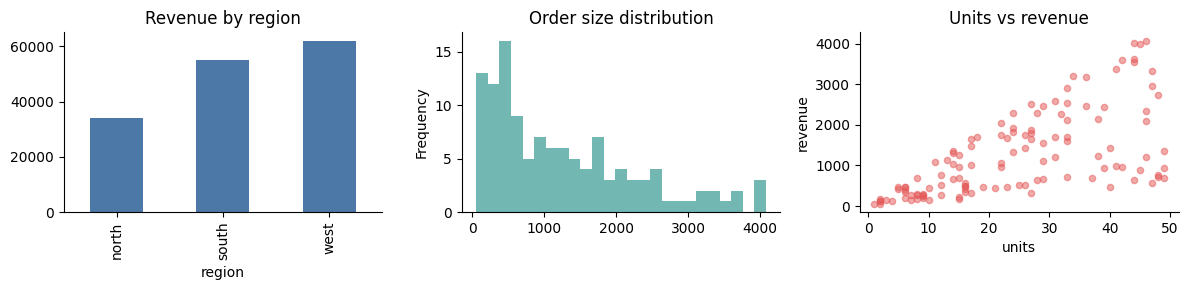

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

sales.groupby("region")["revenue"].sum().plot.bar(ax=axes[0], title="Revenue by region", color="#4c78a8")
sales["revenue"].plot.hist(bins=25, ax=axes[1], title="Order size distribution", color="#72b7b2")
sales.plot.scatter(x="units", y="revenue", ax=axes[2], title="Units vs revenue", alpha=0.5, color="#e45756")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

<a id="20"></a>
## 20. Gotchas cheat sheet

| # | Gotcha | Fix |
|---|---|---|
| 1 | `df[cond]["col"] = x` doesn't stick (chained indexing) | one call: `df.loc[cond, "col"] = x`; enable Copy-on-Write |
| 2 | Int column turns into float after a NaN appears | nullable `Int64` dtype |
| 3 | `.loc` slices are **inclusive**, `.iloc` exclusive | remember: labels include the end |
| 4 | `and`/`or` on masks raises `ValueError: truth value ambiguous` | use `&`/`|` **with parentheses** |
| 5 | Arithmetic gives unexpected NaN | index alignment — check indexes, or use `.add(other, fill_value=0)` |
| 6 | `merge` silently multiplies rows | duplicate keys — use `validate=`, audit with `indicator=True` |
| 7 | `merge` default is `how="inner"` — rows vanish | be explicit about `how=` |
| 8 | `apply(axis=1)` is slow | vectorize: `np.where` / `np.select` / column math |
| 9 | `iterrows` loses dtypes (each row becomes one Series) | `itertuples`, or better: don't loop |
| 10 | ZIP codes / IDs lose leading zeros on read | `read_csv(dtype={"zip": "string"})` |
| 11 | CSV round-trip loses dtypes, re-parses dates | use Parquet |
| 12 | `groupby` on categoricals yields empty combos | `observed=True` |
| 13 | `NaN != NaN` breaks equality checks | `isna()`, `equals()`, `pd.testing.assert_frame_equal` |
| 14 | `inplace=True` blocks chaining, rarely saves memory | assign the result instead |
| 15 | Sorting strings like `small/medium/large` alphabetically | ordered `CategoricalDtype` |

### Where to go next

- **User guide** (the good docs): https://pandas.pydata.org/docs/user_guide/
- *Effective Pandas* (Matt Harrison) — the chaining style used in section 17
- **Polars / DuckDB** — when data outgrows pandas, the concepts here transfer directly

*Notebook built 2026-07-07 · pandas 2.3 · part of the basics-to-expert series.*